In [1]:
# Import necessary libraries
import cv2
from ultralytics import YOLO
import numpy as np
import time
from datetime import datetime
import json
import logging
from IPython.display import clear_output
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import List, Optional, Any

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='detection_test.log'
)


In [2]:
@dataclass
class PersonDetection:
    """Data class for person detection results"""
    detected: bool
    count: int
    confidence: List[float]
    visualization_data: Optional[Any] = None
    timestamp: str = None
    fps: float = 0.0

    def __post_init__(self):
        if self.timestamp is None:
            self.timestamp = datetime.now().isoformat()

    def to_dict(self):
        """Convert to dictionary for logging"""
        return {
            'timestamp': self.timestamp,
            'detected': self.detected,
            'count': self.count,
            'confidence': self.confidence,
            'fps': self.fps
        }

In [3]:
@dataclass
class PerformanceStats:
    """Data class for performance statistics"""
    avg_fps: float
    min_fps: float
    max_fps: float
    total_detections: int
    total_frames: int

    @classmethod
    def empty(cls):
        """Create an empty stats object"""
        return cls(
            avg_fps=0.0,
            min_fps=0.0,
            max_fps=0.0,
            total_detections=0,
            total_frames=0
        )

In [4]:
class DetectionPipeline(ABC):
    """Abstract base class for detection pipelines"""
    def __init__(self, confidence_threshold=0.5):
        self.confidence_threshold = confidence_threshold
        self.fps_history = []
        self.detection_history: List[PersonDetection] = []
        
    @abstractmethod
    def load_model(self):
        """Load the detection model"""
        pass
    
    @abstractmethod
    def detect_persons(self, frame) -> PersonDetection:
        """Detect persons in the frame"""
        pass
        
    def process_frame(self, frame) -> tuple[PersonDetection, Any]:
        start_time = time.monotonic()
        
        # Run detection
        detection = self.detect_persons(frame)
        
        # Calculate FPS
        fps = 1.0 / (time.monotonic() - start_time)
        self.fps_history.append(fps)
        
        # Update detection with FPS
        detection.fps = fps
        
        # Log detection
        self.detection_history.append(detection)
        logging.info(f"Detection event: {json.dumps(detection.to_dict())}")
        
        return detection, detection.visualization_data
    
    @abstractmethod
    def draw_results(self, frame, results):
        """Draw detection results on the frame"""
        pass
    
    def get_performance_stats(self) -> PerformanceStats:
        if not self.fps_history or not self.detection_history:
            return PerformanceStats.empty()
        
        return PerformanceStats(
            avg_fps=float(np.mean(self.fps_history)),
            min_fps=float(np.min(self.fps_history)),
            max_fps=float(np.max(self.fps_history)),
            total_detections=sum(1 for d in self.detection_history if d.detected),
            total_frames=len(self.detection_history)
        )

In [5]:
class UltralyticsDetectionPipeline(DetectionPipeline):
    """Implementation of DetectionPipeline using Ultralytics YOLO"""
    def __init__(self, model_path='yolov8n.pt', confidence_threshold=0.5):
        super().__init__(confidence_threshold)
        self.model_path = model_path
        self.model = self.load_model()
        
    def load_model(self):
        return YOLO(self.model_path)
    
    def detect_persons(self, frame) -> PersonDetection:
        results = self.model(frame)
        
        # Filter for persons (class 0 in COCO dataset)
        persons = [
            box for box in results[0].boxes
            if box.cls == 0 and box.conf > self.confidence_threshold
        ]
        
        return PersonDetection(
            detected=len(persons) > 0,
            count=len(persons),
            confidence=[float(box.conf) for box in persons],
            visualization_data=results[0]
        )
    
    def draw_results(self, frame, results):
        return results.plot()  # Use YOLO's built-in visualization


In [6]:
def test_detection_pipeline(pipeline: DetectionPipeline, camera_id=0, test_duration=30):
    cap = cv2.VideoCapture(camera_id)
    
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open camera {camera_id}")
    
    try:
        start_time = time.monotonic()
        while True:
            current_time = time.monotonic()
            if (current_time - start_time) >= test_duration:
                print(f"\nTest completed. Duration: {current_time - start_time:.2f} seconds")
                break
                
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame")
                break
                
            # Process frame
            detection, results = pipeline.process_frame(frame)
            
            # Draw results
            annotated_frame = pipeline.draw_results(frame, results)
            
            # Display results
            clear_output(wait=True)
            plt.figure(figsize=(12, 8))
            plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            plt.title(f"Detected: {detection.count} persons\nFPS: {detection.fps:.2f}\nElapsed Time: {current_time - start_time:.1f}s")
            plt.axis('off')
            plt.show()
            
    finally:
        cap.release()
        cv2.destroyAllWindows()
        
    # Print performance statistics
    stats = pipeline.get_performance_stats()
    print("\nPerformance Statistics:")
    print(f"Average FPS: {stats.avg_fps:.2f}")
    print(f"Min FPS: {stats.min_fps:.2f}")
    print(f"Max FPS: {stats.max_fps:.2f}")
    print(f"Total Detections: {stats.total_detections}")
    print(f"Total Frames: {stats.total_frames}")
    
    return pipeline

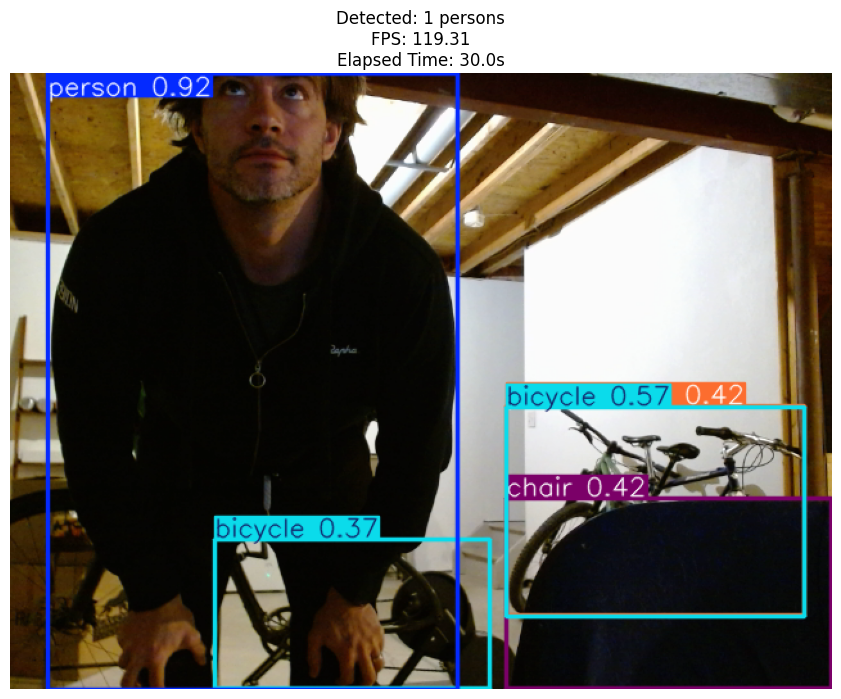


Test completed. Duration: 30.25 seconds

Performance Statistics:
Average FPS: 114.77
Min FPS: 0.69
Max FPS: 125.67
Total Detections: 98
Total Frames: 109


In [7]:
print("Starting detection pipeline test...")
pipeline = UltralyticsDetectionPipeline(
    model_path='yolov8n.pt',
    confidence_threshold=0.5
)
test_results = test_detection_pipeline(pipeline, camera_id=0, test_duration=30)